In [27]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
df = sns.load_dataset("iris")
print(df.head())
print(df.shape)
print(df.dtypes)


   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


In [6]:
numeric_cols = df.select_dtypes(include='number')
stats_df = numeric_cols.agg(['mean', 'median', 'var', 'std', 'min', 'max'])
mode_vals = numeric_cols.mode().iloc[0]
mode_vals.name = 'mode'
stats_df = pd.concat([stats_df, pd.DataFrame(mode_vals).T])
Q1  = numeric_cols.quantile(0.25)
Q1.name = 'Q1'
Q3  = numeric_cols.quantile(0.75)
Q3.name = 'Q3'
IQR = Q3 - Q1
IQR.name = 'IQR'
stats_df = pd.concat([stats_df, pd.DataFrame(Q1).T, pd.DataFrame(Q3).T, pd.DataFrame(IQR).T])
display(stats_df)


,sepal_length,sepal_width,petal_length,petal_width
mean,5.843333,3.057333,3.758000,1.199333
median,5.800000,3.000000,4.350000,1.300000
var,0.685694,0.189979,3.116278,0.581006
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
max,7.900000,4.400000,6.900000,2.500000
mode,5.000000,3.000000,1.400000,0.200000
Q1,5.100000,2.800000,1.600000,0.300000
Q3,6.400000,3.300000,5.100000,1.800000
IQR,1.300000,0.500000,3.500000,1.500000


In [9]:
grouped_stats = df.groupby('species').agg(['mean', 'std'])
display(grouped_stats)

sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650

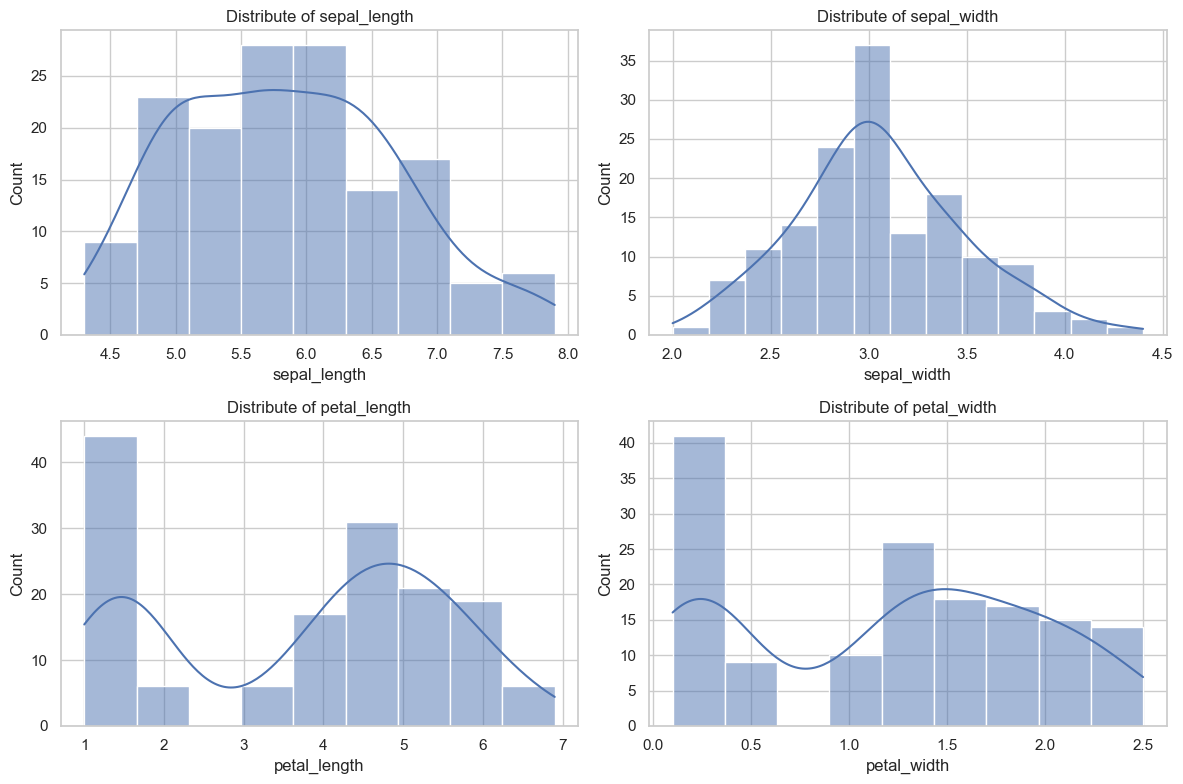

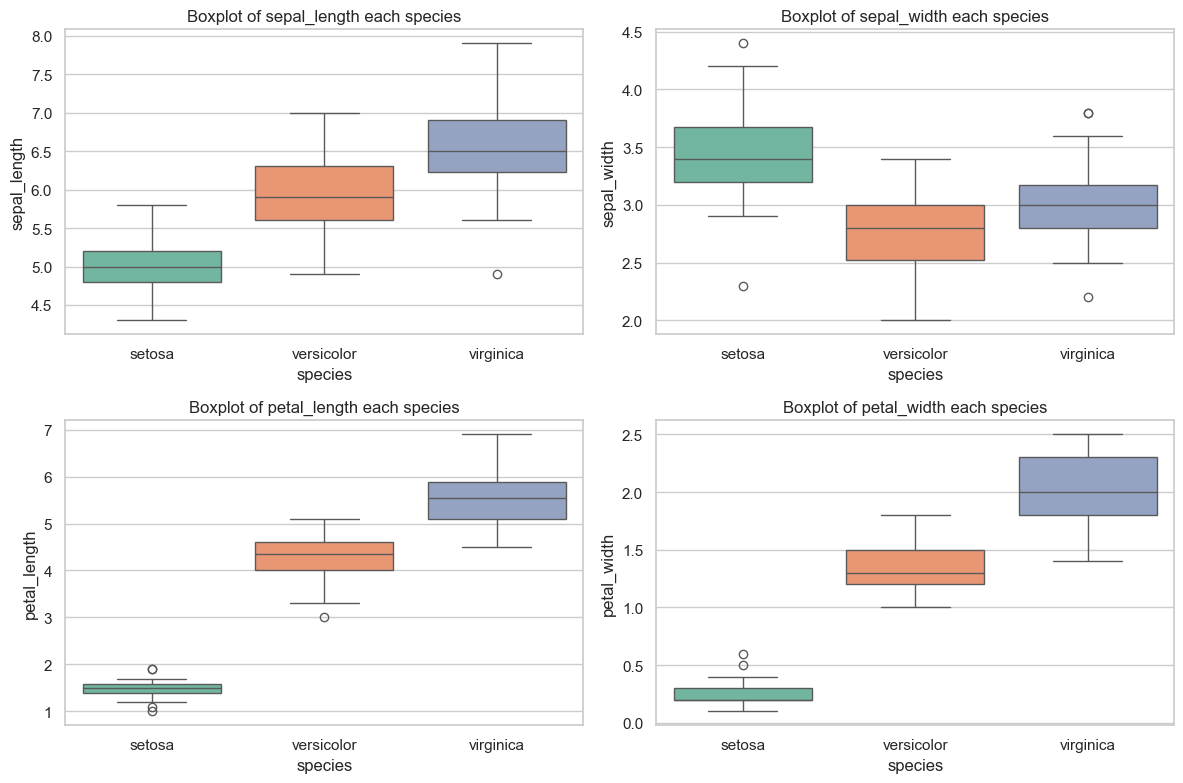

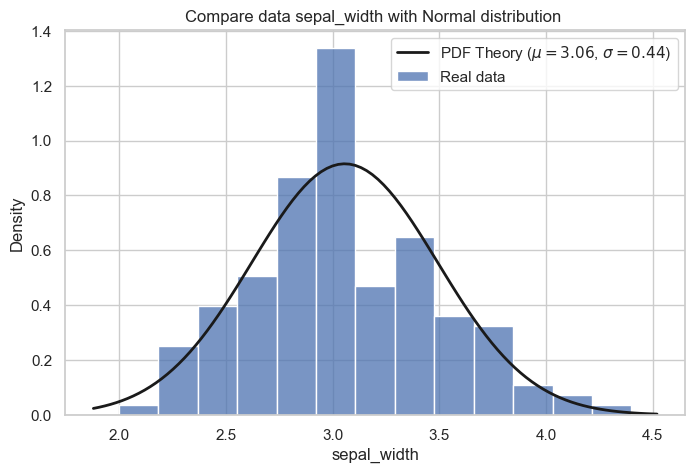

In [42]:
plt.figure(figsize=(12,8))
for i, col in enumerate(numeric_cols.columns, 1):
 plt.subplot(2, 2, i)
 sns.histplot(data=df, x =col, kde=True)
 plt.title(f'Distribute of {col}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,8))
for i, col in enumerate(numeric_cols.columns, 1):
    plt.subplot(2,2,i)
    sns.boxplot(data=df, x='species', y=col, hue='species', palette="Set2", legend=False)
    plt.title(f'Boxplot of {col} each species')
plt.tight_layout()
plt.show()

col_to_test ='sepal_width'
data_test = df[col_to_test]
mu = data_test.mean()
std = data_test.std()

simulated_sample = np.random.normal(mu, std, 1000)
plt.figure(figsize=(8,5))
sns.histplot(data_test, stat="density", kde=False, label = "Real data")

xmin,xmax = plt.xlim()
x=np.linspace(xmin, xmax, 100)
pdf = norm.pdf(x, mu, std)
plt.plot(x,pdf,'k-', linewidth=2, label=f'PDF Theory ($\mu={mu:.2f}$, $\sigma={std:.2f}$)')
plt.title(f'Compare data {col_to_test} with Normal distribution ')
plt.legend()
plt.show()



# Nhận Xét:
-sepal width gần với phân phối chuẩn
-petal length có nhiều đỉnh
-Mức độ khớp cao nhưng vẫn có cột lệch do dữ liệu thực tế không phân phối chuẩn


Covariance:


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.042434,1.274315,0.516271
sepal_width,-0.042434,0.189979,-0.329656,-0.121639
petal_length,1.274315,-0.329656,3.116278,1.295609
petal_width,0.516271,-0.121639,1.295609,0.581006



Correlation:


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


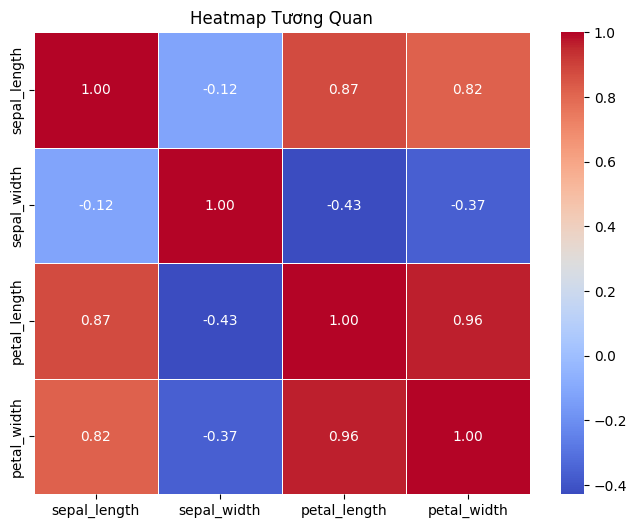

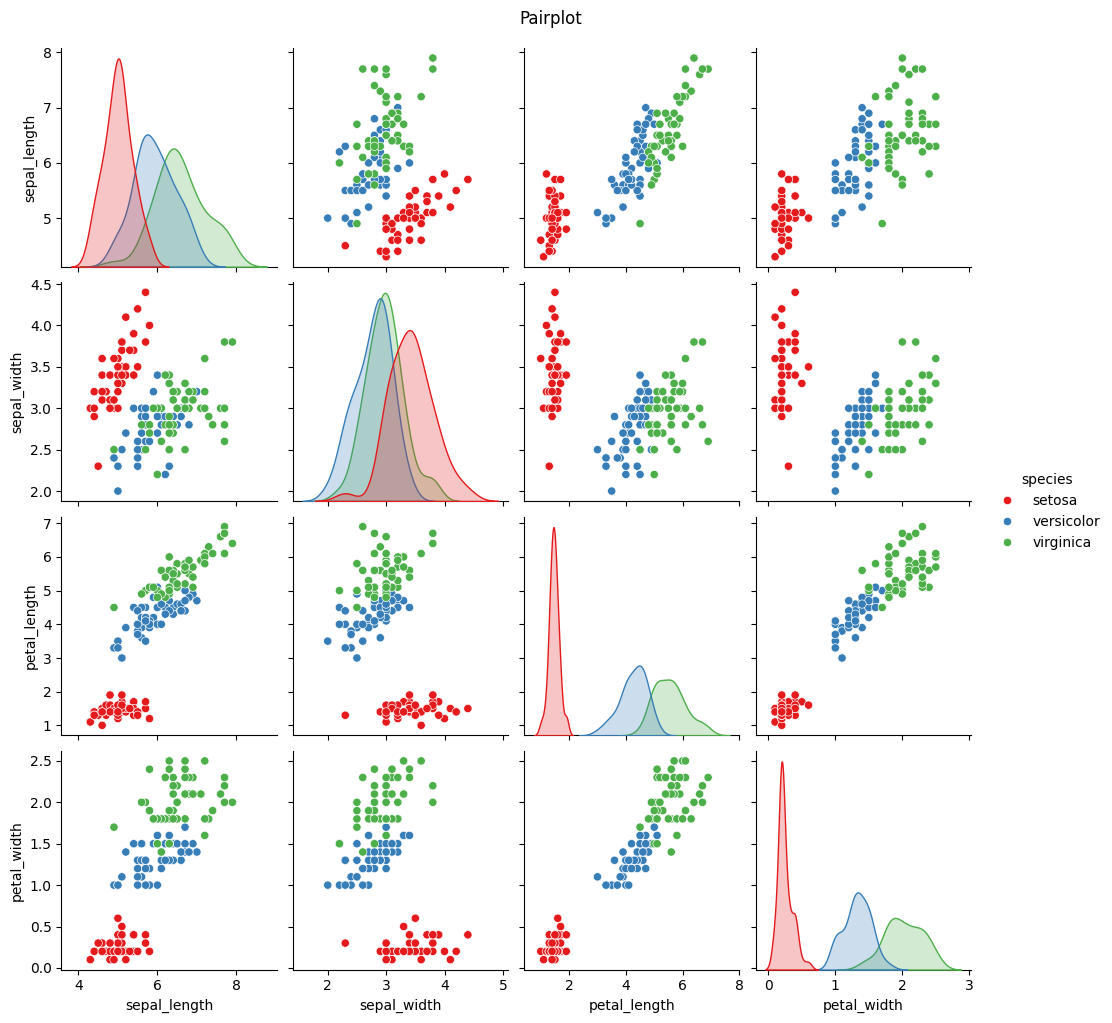

In [34]:
numeric_cols = df.select_dtypes(include='number')
cov_matrix = numeric_cols.cov()
print("Covariance:")
display(cov_matrix)

corr_matrix = numeric_cols.corr()
print("\nCorrelation:")
display(corr_matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap Tương Quan")
plt.show()

sns.pairplot(df, hue="species", palette="Set1")
plt.suptitle("Pairplot", y=1.02)
plt.show()

# Nhận Xét:
- Cặp petal length và petal width có hệ số tương quan cao (0.96) và nó cũng là dấu hiệu của đa cộng tuyến
- Quan hệ giữa các biến: loài versicolor với virginica có xu hướng dính vào nhau


Xác suất thực sự mắc bệnh khi dương tính là: 0.16666666666666669
Khi P(B) thay đổi


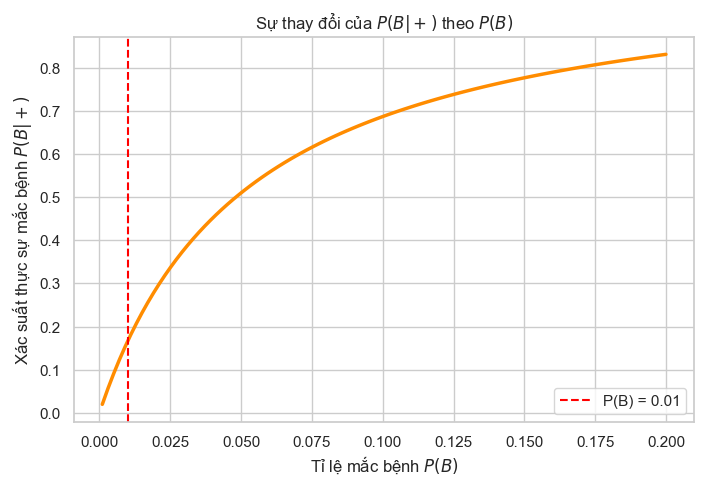

In [40]:
P_B = 0.01
P_pos_B = 0.99
P_pos_NB = 0.05
P_pos = P_pos_B * P_B + P_pos_NB*(1 - P_B)
P_B_pos = (P_pos_B * P_B) / P_pos
print(f"Xác suất thực sự mắc bệnh khi dương tính là: {P_B_pos}")
print("Khi P(B) thay đổi")
p_b_array = np.linspace(0.001, 0.2, 100)
p_pos_array = P_pos_B * p_b_array + P_pos_NB * (1 - p_b_array)
p_b_given_pos_array = (P_pos_B * p_b_array) / p_pos_array
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
plt.plot(p_b_array, p_b_given_pos_array, color='darkorange', linewidth=2.5)
plt.axvline(x=0.01, color='red', linestyle='--', label='P(B) = 0.01')
plt.title("Sự thay đổi của $P(B|+)$ theo $P(B)$")
plt.xlabel("Tỉ lệ mắc bệnh $P(B)$")
plt.ylabel("Xác suất thực sự mắc bệnh $P(B|+)$")
plt.legend()
plt.show()


In [41]:
print("Bonus: bộ lọc Spam Naive Bayes")
P_Spam = 0.3
P_Offer_given_Spam = 0.8
P_Offer_given_Inbox = 0.1

P_Offer = P_Offer_given_Spam * P_Spam + P_Offer_given_Inbox * (1 - P_Spam)
P_Spam_given_Offer = (P_Offer_given_Spam * P_Spam) / P_Offer
print(f"Nhận được email có từ 'offer', xác suất nó là thư rác là: {P_Spam_given_Offer:.4f}")

Bonus: bộ lọc Spam Naive Bayes
Nhận được email có từ 'offer', xác suất nó là thư rác là: 0.7742
